## Kmeans assumption

This example is meant to illustrate situations where k-means will produce unintuitive and possibly unexpected clusters. In the first three plots, the input data does not conform to some implicit assumption that k-means makes and undesirable clusters are produced as a result. In the last plot, k-means returns intuitive clusters despite unevenly sized blobs.

Text(0.5, 1.0, 'Incorrect Number of Blobs')

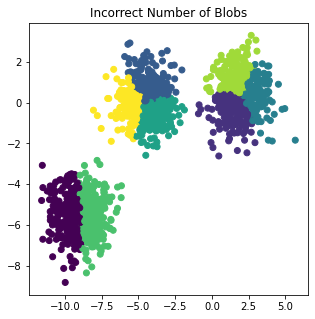

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

plt.figure(figsize=(5, 5))

n_samples = 1500
random_state = 170
X, y = make_blobs(n_samples=n_samples, random_state=random_state)

# Incorrect number of clusters
y_pred = KMeans(n_clusters=8, random_state=random_state).fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.title("Incorrect Number of Blobs")

Text(0.5, 1.0, 'Anisotropicly Distributed Blobs')

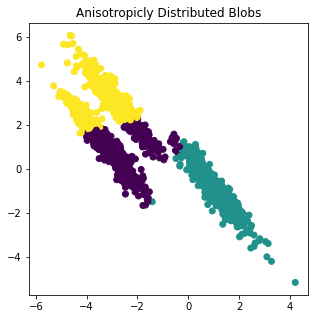

In [2]:
# Anisotropicly distributed data
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)
y_pred_aniso = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_aniso)

plt.figure(figsize=(5, 5))
plt.scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred_aniso)
plt.title("Anisotropicly Distributed Blobs")

Text(0.5, 1.0, 'Unequal Variance')

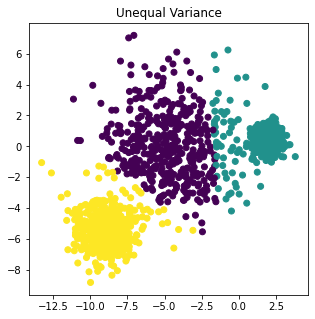

In [3]:
# Different variance
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)
y_pred_varied = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_varied)

plt.figure(figsize=(5, 5))
plt.scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred_varied)
plt.title("Unequal Variance")

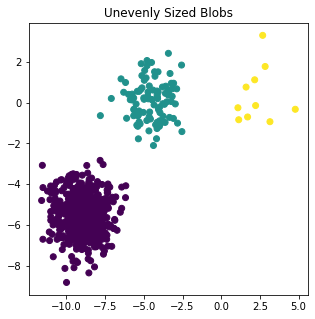

In [28]:
# Unevenly sized blobs
X_filtered = np.vstack((X[y == 0][:500], X[y == 1][:100], X[y == 2][:10]))
y_filtered = [0] * 500 + [1] * 100 + [2] * 10
y_pred_filtered = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_filtered)

plt.figure(figsize=(5, 5))
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred_filtered)
plt.title("Unevenly Sized Blobs")

plt.show()

## Measuring the performance of the clustering

In unsupervised learning measuring the performance of the proposed method is not as trivial as in supervised learning. This is because our dataset _is not labelled_ and therefore without the ground-truth we cannot be sure that the clusters form group of samples that are really close to each other. Just an expert can analyse the samples in each cluster and decide if they are meaningful. But it is time demanding!!

*Question*: How can be measure if the clustering achieved a satisfactory result?

## SILHOUETTE COEFFICIENT
The Silhouette Coefficient is calculated using the mean intra-cluster distance (a) and the mean nearest-cluster distance (b) for each sample. The Silhouette Coefficient for a sample is (b - a) / max(a, b). To clarify, b is the distance between a sample and the nearest cluster that the sample is not a part of. 

In [5]:
from sklearn.metrics import silhouette_samples, silhouette_score
sil_score = silhouette_score(X, y_pred)
sil_score

0.3346934654493441

In [6]:
sil_score = silhouette_score(X_aniso, y_pred_aniso)
sil_score

0.5101937778840281

In [7]:
sil_score = silhouette_score(X_varied, y_pred_varied)
sil_score

0.646798946148098

In [8]:
sil_score = silhouette_score(X_filtered, y_pred_filtered)
sil_score

0.7449036414900642

So, we could iterate on different number of clusters to look for the value that maximise the Silouhette coefficient

In [9]:
for n_cluster in range(2, 15):
    y_pred = KMeans(n_clusters=n_cluster).fit_predict(X)
    sil_coeff = silhouette_score(X, y_pred, metric='euclidean')
    print("For n_clusters={}, The Silhouette Coefficient is {}".format(n_cluster, sil_coeff))


For n_clusters=2, The Silhouette Coefficient is 0.6277375237710934
For n_clusters=3, The Silhouette Coefficient is 0.7333423486262539
For n_clusters=4, The Silhouette Coefficient is 0.5869312405394973
For n_clusters=5, The Silhouette Coefficient is 0.44399650145113373
For n_clusters=6, The Silhouette Coefficient is 0.30935223424091507
For n_clusters=7, The Silhouette Coefficient is 0.32305663465164425
For n_clusters=8, The Silhouette Coefficient is 0.3284983529551298
For n_clusters=9, The Silhouette Coefficient is 0.33615596328495945
For n_clusters=10, The Silhouette Coefficient is 0.3339833141630711
For n_clusters=11, The Silhouette Coefficient is 0.3260537280214362
For n_clusters=12, The Silhouette Coefficient is 0.324636973650514
For n_clusters=13, The Silhouette Coefficient is 0.3221748757024064
For n_clusters=14, The Silhouette Coefficient is 0.3187647432326558


## Alternative: Elbow method

The idea behind elbow method is to run k-means clustering on a given dataset for a range of values of k (num_clusters, e.g k=1 to 10), and for each value of k, calculate sum of squared errors (SSE). This can be easily done through the attribute **inertia_** of the  Kmean algorithm which computes the sum of squared distances of samples to their closest cluster center, weighted by the sample weights if provided.

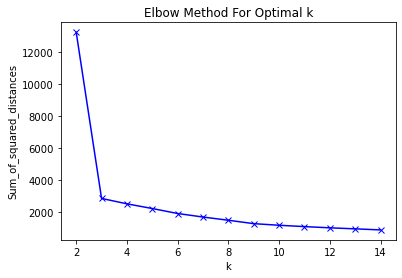

In [10]:
Sum_of_squared_distances = []
K = range(2,15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(X)
    Sum_of_squared_distances.append(km.inertia_)

plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

## RAND INDEX and ADJUSTMENT

The Rand Index measures the agreement between two cluster assignments by considering all pairs of samples and checking whether they are assigned to the same or different clusters in both partitions.

The RI is defined as: $$RI=\frac{TP+TN}{TP+TN+FP+FN}$$ 
where:

- TP (True Positives): Pairs that are in the same cluster in both partitions.
- TN (True Negatives): Pairs that are in different clusters in both partitions.
- FP (False Positives): Pairs that are in the same cluster in the predicted clustering but in different clusters in the ground truth.
- FN (False Negatives): Pairs that are in different clusters in the predicted clustering but in the same cluster in the ground truth.

**Properties**
- RI ranges from 0 to 1.
- 1 means perfect clustering agreement.
- 0.5 means random clustering.
- Sensitive to cluster size imbalance.

The raw RI score is then _“adjusted for chance”_ into the ARI score using the following scheme:

$$ARI =\frac{(RI - Expected\_RI)}{(max(RI) - Expected\_RI)}$$

where $Expected\_RI$ is the expected clusting obtained by a random grouping of the samples. The adjusted Rand index is thus ensured to have a value close to 0.0 for random labeling independently of the number of clusters and samples and exactly 1.0 when the clusterings are identical (up to a permutation).
More precisely:
- ARI ranges from -1 to 1.
- 1 means perfect clustering.
- 0 means clustering is random (i.e., the clustering is no better than chance).
- Negative values indicate worse than random clustering.

ARI is a symmetric measure:

adjusted_rand_score(a, b) == adjusted_rand_score(b, a)

**IMPORTANT**: the ARI index can be computed at condition that the true label for the samples are available!

In [33]:
from sklearn.metrics.cluster import adjusted_rand_score

print(adjusted_rand_score([0, 0, 1, 1], [0, 0, 1, 1]))

print(adjusted_rand_score([0, 0, 1, 1], [1, 1, 0, 0]))

1.0
1.0


In [34]:
adjusted_rand_score([0, 0, 0, 0], [0, 1, 2, 3])

0.0

In [35]:
adjusted_rand_score([0, 0, 1, 2], [0, 0, 1, 1])

0.5714285714285715

Let's analyze the **Adjusted Rand Index (ARI)** calculation for the call above:

---

### **Step 1: Define the Two Clusterings**
We have **two partitions** of four elements:

- **True labels (Ground Truth)**:  
  \[
  [0, 0, 1, 2]
  \]
  - Item 0 and Item 1 belong to Cluster **0**.
  - Item 2 belongs to Cluster **1**.
  - Item 3 belongs to Cluster **2**.

- **Predicted labels (Clustering)**:  
  \[
  [0, 0, 1, 1]
  \]
  - Item 0 and Item 1 belong to Cluster **0**.
  - Items 2 and 3 belong to Cluster **1**.

---

### **Step 2: Compute Pairwise Agreements**
We consider all **pairs of elements** and whether they are **in the same cluster or not** in both partitions.

| Pair (i, j) | Ground Truth Same Cluster? | Predicted Same Cluster? | Case |
|------------|--------------------------|-------------------------|------|
| (1st,2nd) | ✅ (both in 0) | ✅ (both in 0) | **True Positive (TP)** |
| (1st,3rd) | ❌ (0 vs 1) | ❌ (0 vs 1) | **True Negative (TN)** |
| (1st,4th) | ❌ (0 vs 2) | ❌ (0 vs 1) | **True Negative (TN)** |
| (2nd,3rd) | ❌ (0 vs 1) | ❌ (0 vs 1) | **True Negative (TN)** |
| (2nd,4th) | ❌ (0 vs 2) | ❌ (0 vs 1) | **True Negative (TN)** |
| (3rd,4th) | ❌ (1 vs 2) | ✅ (both in 1) | **False Positive (FP)** |

Now, count these cases:

- **True Positives (TP) = 1** 
- **True Negatives (TN) = 3** 
- **False Positives (FP) = 1**
- **False Negatives (FN) = 0**

---

### **Step 3: Compute Raw Rand Index (RI)**
$$ RI = \frac{1 + 3}{1 + 3 + 1 + 0} = \frac{4}{5} = 0.8$$

---

### **Step 4: Compute Adjusted Rand Index (ARI)**
The **Adjusted Rand Index (ARI)** adjusts for random clustering by normalizing against an expected RI under random chance:

$$ARI = \frac{RI - E[RI]}{\max(RI) - E[RI]}$$

The expected **E[RI]** depends on the **cluster sizes** in each partition.

For this example, the expected RI is around **0.5** (approximate value based on combinatorial calculations), and the maximum possible RI is **1**.

Thus,

$$ARI = \frac{0.8 - 0.5}{1 - 0.5} = \frac{0.3}{0.5} = 0.6$$

The actual ARI computed by `sklearn` is **0.57**, which is close to our manual estimation (due to minor variations in expected RI calculations).

---

In [36]:
print(adjusted_rand_score(y, y_pred))

print(adjusted_rand_score(y, y_pred_aniso))

print(adjusted_rand_score(y_varied, y_pred_varied))

print(adjusted_rand_score(y_filtered, y_pred_filtered))


0.2742996239288344
0.6146722349867888
0.8264767338300558
1.0
